## Import libraries

In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

## Load The Data

In [203]:
#load the data
df_cust=pd.read_csv('Customer_Master_Data.csv')
df_trans=pd.read_csv('Customer_Transactions.csv')

In [204]:
df_cust.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [205]:
df_trans.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


## Finding Missing Values 

In [206]:
missing_values_customers=df_cust.isnull().sum()
print('Misiing values in customer master are:\n')
print(missing_values_customers)

missing_values_transaction=df_trans.isnull().sum()
print('\nMisiing values in customer transactions are:\n')
print(missing_values_transaction)

Misiing values in customer master are:

CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64

Misiing values in customer transactions are:

CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64


In [207]:
missing_values_transaction=df_trans.isnull().sum()
missing_values_transaction


CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64

## Changing Data Type As Required For Further Analysis.

#### Ensuring Dates In Columns Are In Datetime Format.

In [208]:
df_cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB


In [209]:
df_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1), object(2)
memory usage: 540.4+ KB


In [210]:
#joindate & TransactionDate column is in object datatype it should be in datetime format.

#converting joindate & TransactionDate column in datetime format.

df_cust['JoinDate']=pd.to_datetime(df_cust['JoinDate'])
df_trans['TransactionDate']=pd.to_datetime(df_trans['TransactionDate'])

### Checking Shape & Structure 

In [211]:
print(f"Total Customer Records In The Master Data :",df_cust.shape[0] )
print(f"Total Transactions Records :",df_trans.shape[0] )

Total Customer Records In The Master Data : 1000
Total Transactions Records : 23050


## Checking Other Details

### Keep only valid transaction

#### We keep transactions whose CustomerID exists in the master customer data

In [212]:
df_trans=df_trans[df_trans["CustomerID"].isin(df_cust["CustomerID"])].copy()
df_trans.shape[0]

23050

### Checking Duplicate Entries

In [213]:
duplicate=df_trans[df_trans.duplicated()]
print("\nDuplicate Entries in Transactions are:\n")
print(duplicate)
duplicate_trs=df_cust[df_cust.duplicated()]
print("\nDuplicate Entries in Customer Master are:\n ")
print(duplicate_trs)


Duplicate Entries in Transactions are:

Empty DataFrame
Columns: [CustomerID, TransactionDate, TransactionAmount]
Index: []

Duplicate Entries in Customer Master are:
 
Empty DataFrame
Columns: [CustomerID, Name, Email, Gender, Age, City, MaritalStatus, NumChildren, JoinDate]
Index: []


# RFM Calculations

#### Referance Date = max transaction date + 1 day

In [214]:
ref_date=df_trans["TransactionDate"].max() + timedelta(days=1)
ref_date

Timestamp('2025-07-30 00:00:00')

### For Each Customer :

#### -LastTransDate = most recent purchase Date

#### -Frequency = Number of rows (Purchases)

#### -Monetary = Sum of Transaction Amount

In [215]:
# Defining temporary variable of Calculation of RFM is rfm.
rfm=(df_trans.groupby("CustomerID").agg
     (LastTransDate=("TransactionDate","max"),
      Frequency = ("TransactionDate","count"),
      Monetary = ("TransactionAmount","sum")).reset_index())
rfm.head()

,CustomerID,LastTransDate,Frequency,Monetary
0,CUST10000,2025-07-17,23,21265.49
1,CUST10001,2025-06-25,30,28654.31
2,CUST10002,2025-07-12,24,23884.03
3,CUST10003,2025-05-10,25,24206.03
4,CUST10004,2025-07-22,19,25565.30


#### Calculating Recency (in days) = Difference From ref_date

In [216]:
rfm["Recency"]=(ref_date-rfm["LastTransDate"]).dt.days
rfm.head()

,CustomerID,LastTransDate,Frequency,Monetary,Recency
0,CUST10000,2025-07-17,23,21265.49,13
1,CUST10001,2025-06-25,30,28654.31,35
2,CUST10002,2025-07-12,24,23884.03,18
3,CUST10003,2025-05-10,25,24206.03,81
4,CUST10004,2025-07-22,19,25565.30,8


#### Arranging columns as Required

In [217]:
rfm = rfm[["CustomerID","Recency","Frequency","Monetary"]]
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,CUST10000,13,23,21265.49
1,CUST10001,35,30,28654.31
2,CUST10002,18,24,23884.03
3,CUST10003,81,25,24206.03
4,CUST10004,8,19,25565.30


### Defining the Scores R/M/F

#### Recency (Lower is better)

##### Recency<=30   days : 5

##### Recency<=60   days : 4

##### Recency<=120  days : 3

##### Recency<=240  days : 2

##### Recency>240   days : 1

In [218]:
r_bins = [0,30,60,120,240,float("inf")] # creating bins for range
r_labels = [5,4,3,2,1] # creating labels for range in bins (reverced because lower recency is better)

# "pd.cut" is function in pandas which cuts values one by one and creates grouping by bins and labels

# "include_lowest=True" means include the lowest in range

# "right=True" means intervals are right closed (0,30] means 30 is included in range 0 to 30 
#                                and (30,60] 30 is not included in range 30 to 60 and so on,
#                                for continous range. 

# ".astype(int)" returns values as numerical integer type.

rfm["R_score"] = pd.cut((rfm["Recency"]), bins=r_bins, labels=r_labels, include_lowest=True, right=True).astype(int)

rfm.head() 


,CustomerID,Recency,Frequency,Monetary,R_score
0,CUST10000,13,23,21265.49,5
1,CUST10001,35,30,28654.31,4
2,CUST10002,18,24,23884.03,5
3,CUST10003,81,25,24206.03,3
4,CUST10004,8,19,25565.30,5


### Frequency (Higher is better)

##### Frequency <=07  :  1

##### Frequency <=14  :  2

##### Frequency <=21  :  3

##### Frequency <=28  :  4

##### Frequency  >28  :  5

In [219]:
f_bins = [0,7,14,21,28,float("inf")] # creating bins for range
f_labels = [1,2,3,4,5]               # creating labels for range in bins (not reverced because Higher frequency is better)

# "pd.cut" is function in pandas which cuts values one by one and creates grouping by bins and labels

# "include_lowest=True" means include the lowest in range

# "right=True" means intervals are right closed (0,7] means 7 is included in range 0 to 7 
#                                and (7,14] 7 is not included in range 7 to 14 and so on,
#                                for continous range. 

# ".astype(int)" returns values as numerical integer type.

rfm["F_score"]=pd.cut(rfm["Frequency"],bins=f_bins,labels=f_labels,include_lowest=True,right=True).astype(int)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score
0,CUST10000,13,23,21265.49,5,4
1,CUST10001,35,30,28654.31,4,5
2,CUST10002,18,24,23884.03,5,4
3,CUST10003,81,25,24206.03,3,4
4,CUST10004,8,19,25565.30,5,3


### Monetary (Higher is better)

##### Monetary <= 10000  : 1

##### Monetary <= 20000  : 2

##### Monetary <= 30000  : 3

##### Monetary <= 40000  : 4

##### Monetary > 40000   : 5

In [220]:
m_bins=[0,10000,20000,30000,40000,float("inf")]    # creating bins for range
m_labels=[1,2,3,4,5]                               # creating labels for range in bins (not reverced because Higher Monetary is better)

# "pd.cut" is function in pandas which cuts values one by one and creates grouping by bins and labels

# "include_lowest=True" means include the lowest in range

# "right=True" means intervals are right closed (0,10000] means 10000 is included in range 0 to 10000 
#                                and (10000,20000] 10000 is not included in range 10000 to 20000 and so on,
#                                for continous range. 

# ".astype(int)" returns values as numerical integer type.
rfm["M_score"]=pd.cut(rfm["Monetary"],bins=m_bins,labels=m_labels,include_lowest=True,right=True).astype(int)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,CUST10000,13,23,21265.49,5,4,3
1,CUST10001,35,30,28654.31,4,5,3
2,CUST10002,18,24,23884.03,5,4,3
3,CUST10003,81,25,24206.03,3,4,3
4,CUST10004,8,19,25565.30,5,3,3


## RFM SCORE (STRING)

In [221]:
rfm["RFM_Score"]=(rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str))
# converting into sting beacuse we want concat value nor addition value.
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,CUST10000,13,23,21265.49,5,4,3,543
1,CUST10001,35,30,28654.31,4,5,3,453
2,CUST10002,18,24,23884.03,5,4,3,543
3,CUST10003,81,25,24206.03,3,4,3,343
4,CUST10004,8,19,25565.30,5,3,3,533


### Naming the segments

In [222]:
def segment_row(r,f,m):
    if(r>=4) and (f>=4) and (m>=4):
        return "Champions"
    elif(f>=4) and (r>=2):
        return "Loyal"
    elif(r>=4) and (2<=f<=3):
        return "Potential Loyalist"
    elif(r<=2) and (f>=3):
        return "Risk"
    elif (m>=4) and (2<=f<=3) and (r>=3):
        return "Big Spenders"
    elif (r==1) and (f<=2) and (m<=2):
        return "Lost"
    else:
        return "Others"
        
rfm["Segment"]=[segment_row(r,f,m) for r,f,m in zip(rfm["R_score"],rfm["F_score"],rfm["M_score"])]
# creating segment column in rfm DataFrame.
# loop r,f,m picks values from zip function defined.
# zip function in loop Gives values from defined columns from rfm one by one and gives output in variable r,f,m in loop .
rfm.head()
        

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,CUST10000,13,23,21265.49,5,4,3,543,Loyal
1,CUST10001,35,30,28654.31,4,5,3,453,Loyal
2,CUST10002,18,24,23884.03,5,4,3,543,Loyal
3,CUST10003,81,25,24206.03,3,4,3,343,Loyal
4,CUST10004,8,19,25565.30,5,3,3,533,Potential Loyalist


In [223]:
segment_customers = rfm["Segment"].value_counts().reset_index()
segment_customers.columns=["Segment","Customer_Count"] # changing the columns header name

# Basic Buisness Analysis


In [224]:
print("\n ============= SIMPLE BUSINESS ANALYSIS ===========")
#  overall business summary

total_customers = rfm["CustomerID"].nunique() #or .shape[0]

total_revenue = rfm["Monetary"].sum()

avg_revenue_per_customer=rfm["Monetary"].mean()

print(f"\n Total customers :{total_customers}")

print(f"\n Total Revenue : Rs {total_revenue}")

print(f"\n Average Revenue per customer  : Rs {avg_revenue_per_customer:.2f}")

# customer in each segment

print(f"\n\n Numbers of Customers in each Segments :\n\n ")
print(segment_customers)

#revenue for each segment

segment_revenue=rfm.groupby("Segment")["Monetary"].sum().reset_index()

print(f"\n\nRevenue Contribution by Each Segment :\n\n")
print(segment_revenue)


 ============= SIMPLE BUSINESS ANALYSIS ===========

 Total customers :1000

 Total Revenue : Rs 23053199.66

 Average Revenue per customer  : Rs 23053.20


 Numbers of Customers in each Segments :

 
              Segment  Customer_Count
0               Loyal             542
1  Potential Loyalist             248
2           Champions              84
3              Others              77
4                Risk              47
5                Lost               2


Revenue Contribution by Each Segment :


              Segment     Monetary
0           Champions   2791699.03
1                Lost     29221.39
2               Loyal  13381926.89
3              Others   1416376.98
4  Potential Loyalist   4495435.99
5                Risk    938539.38


# Visualisation



 Numbers of Customers in each Segments :

 
              Segment  Customer_Count
0               Loyal             542
1  Potential Loyalist             248
2           Champions              84
3              Others              77
4                Risk              47
5                Lost               2


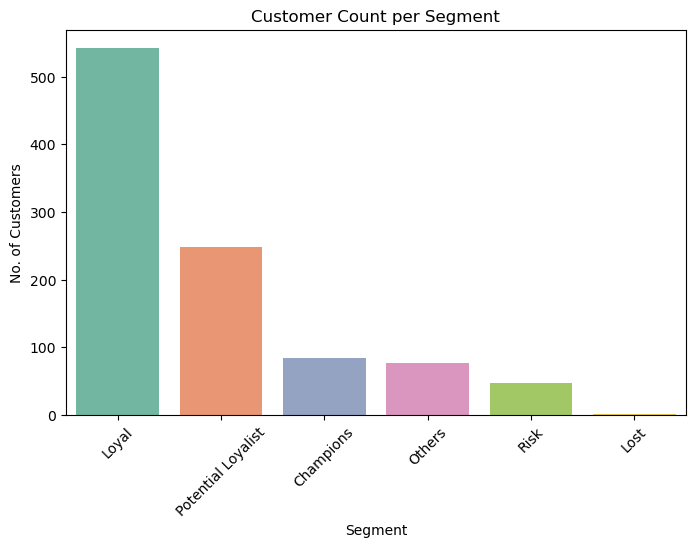

In [225]:
# Bar chart

# printing Customer in each segment with the chart

print(f"\n\n Numbers of Customers in each Segments :\n\n ")
print(segment_customers)

plt.figure(figsize=(8,5))
sns.barplot(x="Segment",y="Customer_Count",data=segment_customers, palette="Set2")

# Add lebals to the bars

plt.title("Customer Count per Segment")
plt.xlabel("Segment")
plt.ylabel("No. of Customers")
plt.xticks(rotation=45) # rotates the x axis bar lebals
plt.show()




 Revenue Contribution by each Segment :


              Segment     Monetary
0           Champions   2791699.03
1                Lost     29221.39
2               Loyal  13381926.89
3              Others   1416376.98
4  Potential Loyalist   4495435.99
5                Risk    938539.38




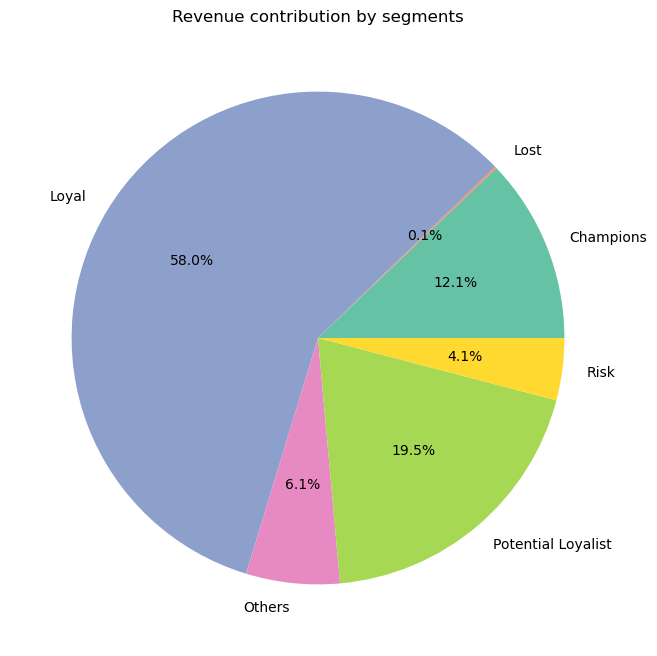

In [226]:
t_revenue=rfm.groupby("Segment")["Monetary"].sum().reset_index()

print(f"\n Revenue Contribution by each Segment :\n")
print(f"\n{segment_revenue}\n\n")

# pie chart
plt.figure(figsize=(8,8))
plt.pie(segment_revenue["Monetary"],labels=segment_revenue["Segment"],autopct="%1.1f%%",colors=sns.color_palette("Set2"))
plt.title("Revenue contribution by segments")
plt.show()




Recency vs Monetary by Segment:


   Recency  Monetary             Segment
0       13  21265.49               Loyal
1       35  28654.31               Loyal
2       18  23884.03               Loyal
3       81  24206.03               Loyal
4        8  25565.30  Potential Loyalist


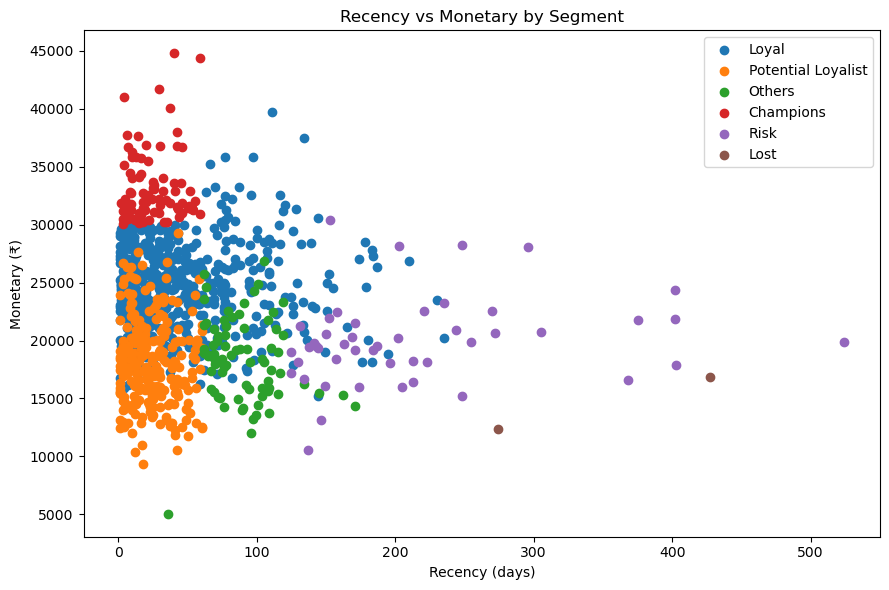

In [227]:
scatterplt=rfm[["Recency","Monetary","Segment"]]
print("\n\nRecency vs Monetary by Segment:\n\n")
print(scatterplt.head())

# figure size
plt.figure(figsize=(9,6))

for seg in rfm['Segment'].unique():  #Loop through each customer segment
    data = rfm[rfm['Segment'] == seg]  #Select only the rows for that segment
    plt.scatter(data['Recency'], data['Monetary'], label=seg)  #scatter points 
    
#Add labels and title
plt.xlabel('Recency (days)')
plt.ylabel('Monetary (₹)')
plt.title('Recency vs Monetary by Segment')


plt.legend()
plt.tight_layout()
plt.show()


### Pareto: Top 20% customers contribution



Top 20% customers contribute 27.03% of revenue




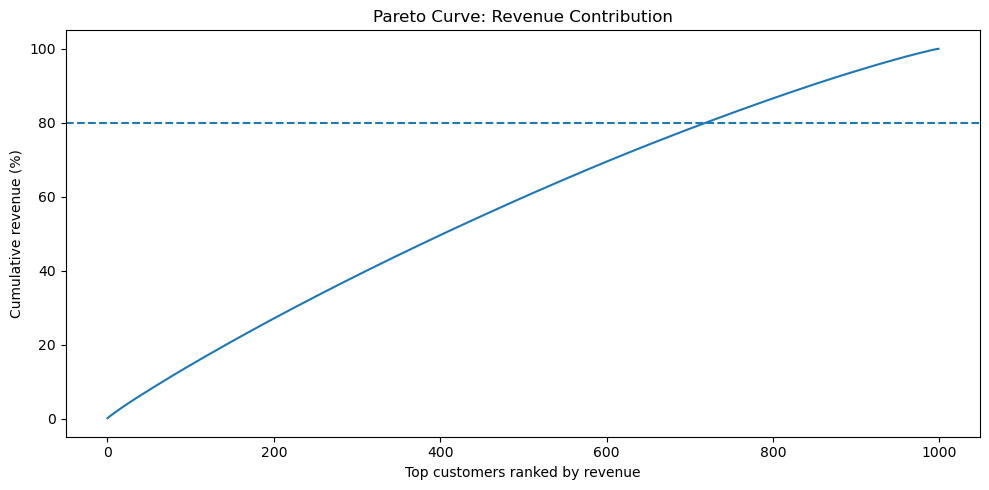




===========================================================THANKYOU====================================================================


In [228]:
# Sort customers by revenue (highest first)
cust = rfm[['CustomerID', 'Monetary']].sort_values('Monetary', ascending=False).reset_index(drop=True)

# Calculate cumulative revenue
cust['cum_rev'] = cust['Monetary'].cumsum()

# Finding the total revenue
total = cust['Monetary'].sum()

# Convert cumulative revenue into percent
cust['cum_pct'] = (cust['cum_rev'] / total) * 100

# Identifying top 20% customers by count
top20 = int(0.2 * len(cust))           #0.2 * len(cust)represent If 100 customers → top 20 customers
                                        #If 500 customers → top 100 customers means total len multiplied by .2 to get top 20

# Calculate their revenue contribution
top20_pct = cust['Monetary'][:top20].sum() / total * 100 # what % of total money came from top 20% of customers

print(f"\n\nTop 20% customers contribute {top20_pct:.2f}% of revenue\n\n")

# Pareto curve

plt.figure(figsize=(10,5))
plt.plot(cust['cum_pct'])  #line plot

plt.axhline(80, linestyle='--')  #horizontal dashed line at 80%

plt.xlabel("Top customers ranked by revenue") #Label for x-axis
plt.ylabel("Cumulative revenue (%)")          #Label for y-axis
plt.title("Pareto Curve: Revenue Contribution")  #Adds a title on top of the graph.
plt.tight_layout() #Adjusts spacing (labels and title fit neatly)
plt.show() # isplays curve

print("\n\n\n===========================================================THANKYOU====================================================================")


In [229]:
#                             >>>>>        Key business insights & recommended actions       <<<<<


#  1. Champions & Big Spenders:

#                             Only 27% of revenue comes from the top 20% customers (not 80% like many businesses)
#                             Revenue is spread out, so you should not focus only on top customers.
#                             Mid-level customers also matter and should receive offers or deals.

#  2. Recent Buyers vs Hibernating Customers:

#                Recent Buyers: 
#                              Bought recently but not many times.

#                             > Good chance to turn them into loyal customers
#                               with welcome offers or product suggestions.

#                Hibernating Customers: 
#                                     Haven't bought for a long time and buy rarely.

#                                   > Send light reminders or small offers—don’t 
#                                     spend too much marketing budget here.

#  3. Potential Loyalists:

#                 These customers:

#                                  > Buy moderately often

#                                  > Buy somewhat recently

#                                  > Spend a fair amount

#            >> They are very close to becoming Loyal Customers <<

#    Give them reward points, free shipping, or personalized product suggestions.



# 4. At-Risk Customers:

#                     These customers used to buy often, but now they have stopped buying.

#                     Send them:

#                               > “We miss you” emails
                                
#                               > Special comeback discount
                                
#                               > Personalized messages

#                     Goal: bring them back before they churn.



# 5. Pareto & LTV:

#                In many businesses : Top 20% customers usually bring 80% of revenue.

#                But in data : Top 20% bring only 27% of revenue.

#                Result:
#                        revenue comes from many different customers.
                        
#                        You should calculate Customer Lifetime Value (LTV) for each segment.
                        
#                        Also perform cohort analysis to see how customers behave over time.